In [ ]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
import os
import copy
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier("/content/drive/My Drive/haarcascade_frontalface_default.xml")

In [ ]:
def detect_face(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )

    # if no face is detected, use the original image
    if len(faces) == 0:
        return cv2.resize(image, (224, 224))

    # use the largest detected face
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    face = image[y : y + h, x : x + w]
    face = cv2.resize(face, (224, 224))
    return face


class FaceImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.base_dataset = ImageFolder(root)
        self.samples = self.base_dataset.samples
        self.classes = self.base_dataset.classes
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # load
        image = cv2.imread(img_path)
        image = detect_face(image)

        # convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# define dataset paths
# CK_new / JAFFE_new
train_dir = "/content/drive/My Drive/CK_new/train"
test_dir = "/content/drive/My Drive/CK_new/test"

train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

# base dataset
base_train_dataset = ImageFolder(train_dir)
test_dataset = FaceImageFolder(test_dir, transform=eval_transform)

train_size = int(0.8 * len(base_train_dataset))
val_size = len(base_train_dataset) - train_size

train_subset, val_subset = random_split(
    base_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

# rebuild datasets with face detection and separate transforms
train_dataset_full = FaceImageFolder(train_dir, transform=train_transform)
val_dataset_full = FaceImageFolder(train_dir, transform=eval_transform)

train_dataset = torch.utils.data.Subset(train_dataset_full, train_subset.indices)
val_dataset = torch.utils.data.Subset(val_dataset_full, val_subset.indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# load EfficientNet model
efficientnet_b0_model = models.efficientnet_b0(pretrained=True)
num_features = efficientnet_b0_model.classifier[1].in_features
efficientnet_b0_model.classifier = nn.Sequential(
    nn.Dropout(0.2), nn.Linear(num_features, 6)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    efficientnet_b0_model.parameters(), lr=0.0001, weight_decay=1e-4
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet_b0_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# training with validation accuracy per epoch
num_epochs = 25
train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

best_val_accuracy = 0.0
best_model_wts = copy.deepcopy(efficientnet_b0_model.state_dict())

for epoch in range(num_epochs):
    efficientnet_b0_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet_b0_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_accuracy = 100 * correct / total
    train_acc_list.append(train_accuracy)
    train_loss_list.append(running_loss / len(train_loader))

    # evaluate on validation set after each epoch
    efficientnet_b0_model.eval()
    correct_val = 0
    total_val = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet_b0_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_accuracy = 100 * correct_val / total_val
    val_acc_list.append(val_accuracy)
    val_loss_list.append(val_loss / len(val_loader))

    # save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_wts = copy.deepcopy(efficientnet_b0_model.state_dict())

    print(
        f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, "
        f"Train Accuracy: {train_accuracy:.2f}%, Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch [1/25], Loss: 1.7903, Train Accuracy: 15.38%, Val Accuracy: 21.74%
Epoch [2/25], Loss: 1.5711, Train Accuracy: 54.40%, Val Accuracy: 39.13%
Epoch [3/25], Loss: 1.3786, Train Accuracy: 76.37%, Val Accuracy: 45.65%
Epoch [4/25], Loss: 1.1504, Train Accuracy: 82.97%, Val Accuracy: 54.35%
Epoch [5/25], Loss: 0.9931, Train Accuracy: 82.97%, Val Accuracy: 56.52%
Epoch [6/25], Loss: 0.8160, Train Accuracy: 84.62%, Val Accuracy: 58.70%
Epoch [7/25], Loss: 0.7010, Train Accuracy: 87.36%, Val Accuracy: 65.22%
Epoch [8/25], Loss: 0.5940, Train Accuracy: 90.66%, Val Accuracy: 69.57%
Epoch [9/25], Loss: 0.5216, Train Accuracy: 89.56%, Val Accuracy: 69.57%
Epoch [10/25], Loss: 0.4478, Train Accuracy: 89.56%, Val Accuracy: 71.74%
Epoch [11/25], Loss: 0.3794, Train Accuracy: 92.31%, Val Accuracy: 73.91%
Epoch [12/25], Loss: 0.3469, Train Accuracy: 93.96%, Val Accuracy: 76.09%
Epoch [13/25], Loss: 0.2781, Train Accuracy: 96.70%, Val Accuracy: 78.26%
Epoch [14/25], Loss: 0.2603, Train Accuracy: 98

Best Validation Accuracy: 80.43%
Final Test Accuracy: 79.38%


<Figure size 800x600 with 0 Axes>

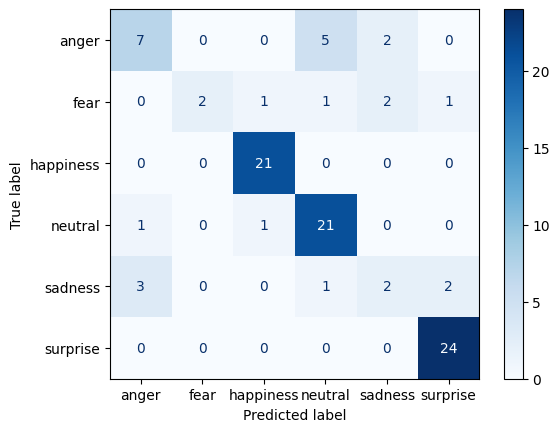


Classification Report:
              precision    recall  f1-score   support

       anger     0.6364    0.5000    0.5600        14
        fear     1.0000    0.2857    0.4444         7
   happiness     0.9130    1.0000    0.9545        21
     neutral     0.7500    0.9130    0.8235        23
     sadness     0.3333    0.2500    0.2857         8
    surprise     0.8889    1.0000    0.9412        24

    accuracy                         0.7938        97
   macro avg     0.7536    0.6581    0.6682        97
weighted avg     0.7869    0.7938    0.7713        97



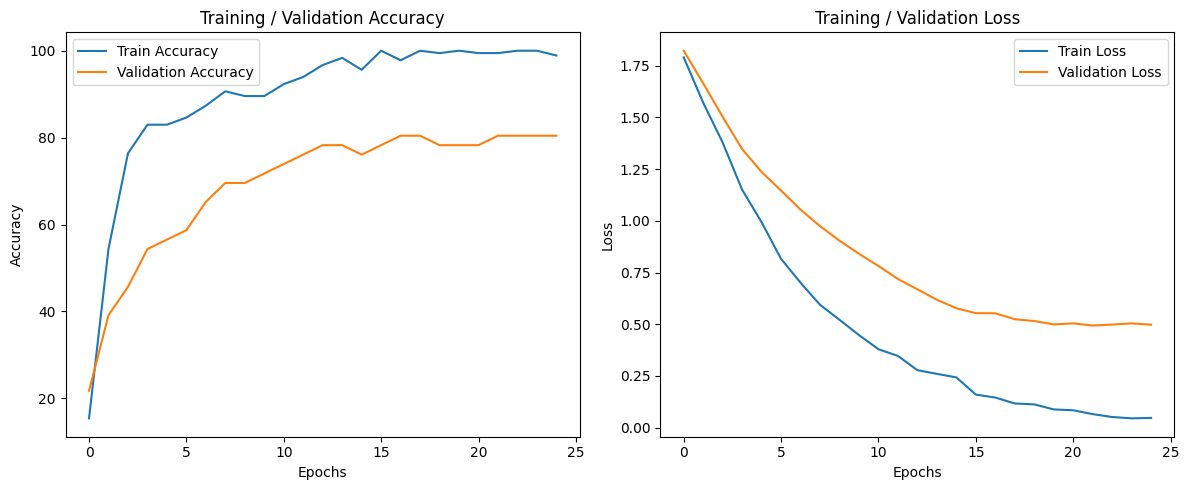

In [ ]:
# final evaluation and confusion matrix
efficientnet_b0_model.load_state_dict(best_model_wts)
efficientnet_b0_model.eval()
y_true = []
y_pred = []
total = 0
correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet_b0_model(images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

final_test_accuracy = 100 * correct / total
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
print(f"Final Test Accuracy: {final_test_accuracy:.2f}%")

conf_matrix = confusion_matrix(y_true, y_pred)
cm_display = ConfusionMatrixDisplay(conf_matrix, display_labels=test_dataset.classes)

plt.figure(figsize=(8, 6))
cm_display.plot(cmap=plt.cm.Blues)
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_true, y_pred, target_names=test_dataset.classes, digits=4, zero_division=0
    )
)

# plot accuracy and loss
plt.figure(figsize=(12, 5))

# accuracy plot
plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training / Validation Accuracy")

# loss plot
plt.subplot(1, 2, 2)
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training / Validation Loss")

plt.tight_layout()
plt.show()

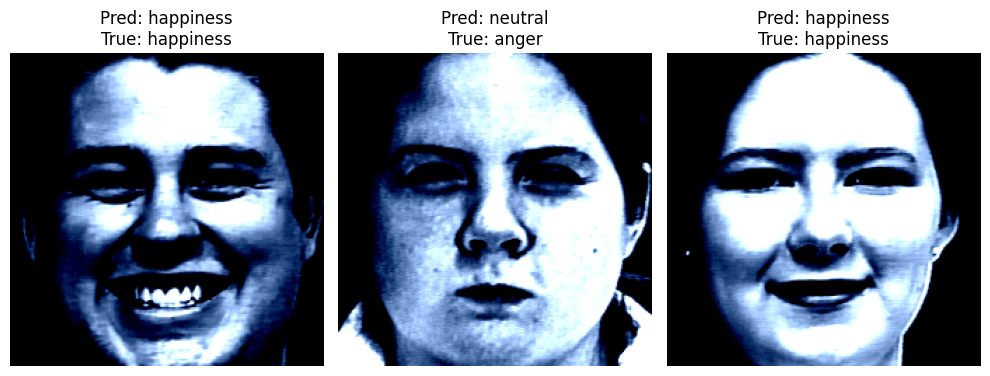

In [ ]:
import random

# get some random test samples
indices = random.sample(range(len(test_dataset)), 3)

plt.figure(figsize=(10, 4))

for i, idx in enumerate(indices):
    image, label = test_dataset[idx]

    # model expects batch
    input_img = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = efficientnet_b0_model(input_img)
        _, pred = torch.max(output, 1)

    pred_label = test_dataset.classes[pred.item()]
    true_label = test_dataset.classes[label]

    # convert tensor to displayable image
    img_np = image.permute(1, 2, 0).numpy()

    plt.subplot(1, 3, i + 1)
    plt.imshow(img_np)
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()